# Cairo Real Estate — Exploratory Data Analysis Notebook
**Author:** Marwan Ashraf  
**Last updated:** 5/20/2026 <br>
**Purpose:** Exploratory Data Analysis to get to know the cairo relastate market

In [36]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy 

import yaml

In [37]:
with open('../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

In [38]:
df = pd.read_parquet(config['data_source']['file_paths']['cleaned_dataset'])

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70344 entries, 0 to 70343
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        70342 non-null  string        
 1   city                         70344 non-null  string        
 2   district                     70344 non-null  string        
 3   area                         63779 non-null  string        
 4   neighborhood                 40625 non-null  string        
 5   property_type                70344 non-null  string        
 6   sale_or_rent                 70344 non-null  string        
 7   price                        70344 non-null  Int64         
 8   seller_name                  70344 non-null  string        
 9   property_subtype             70344 non-null  string        
 10  bedrooms                     70344 non-null  string        
 11  bathrooms                    70344 non-nu

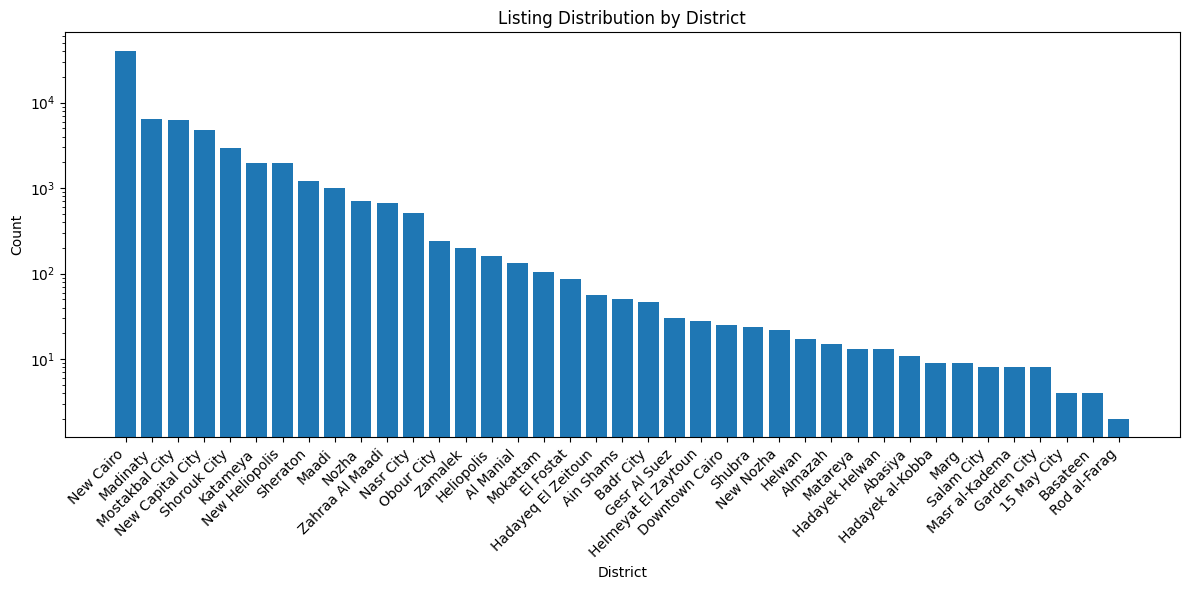

In [22]:
# First thing let's look at each variables individually understand them and build up from there 
# Let's start simply by district
counts = df['district'].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(counts.index, counts.values)
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.xlabel('District')
plt.ylabel('Count')
plt.title('Listing Distribution by District')
plt.tight_layout()
plt.show()

In [23]:
## The data is mostly skewed in the new places this is normal because the source of our scraping advertiser/realstate agencies 
## heavly invest in new district compared to already populated districts 


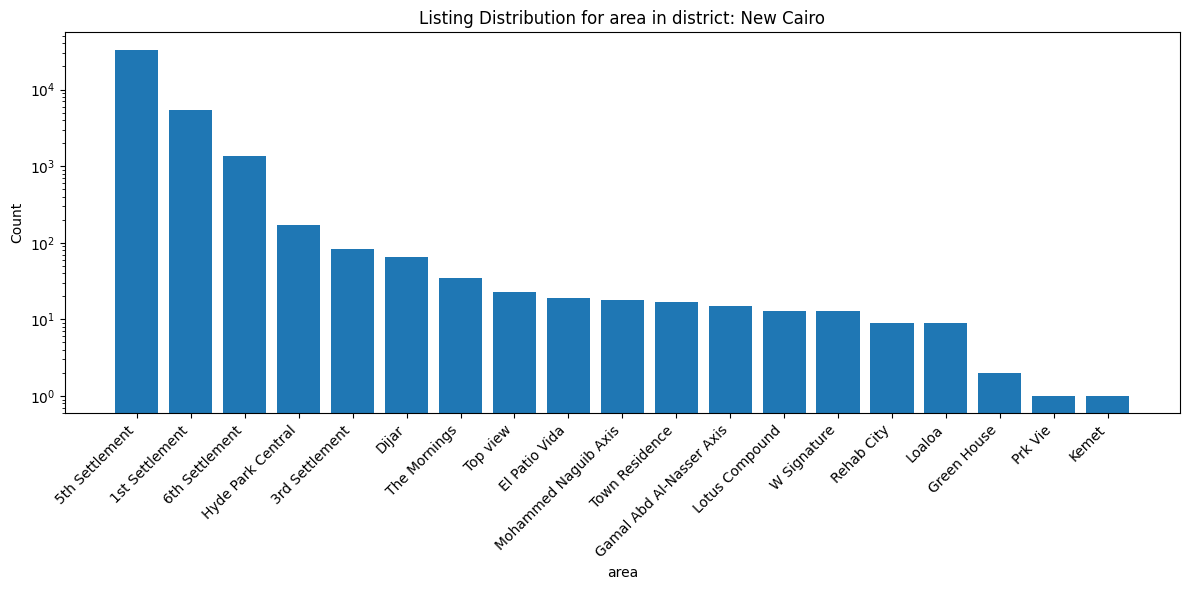

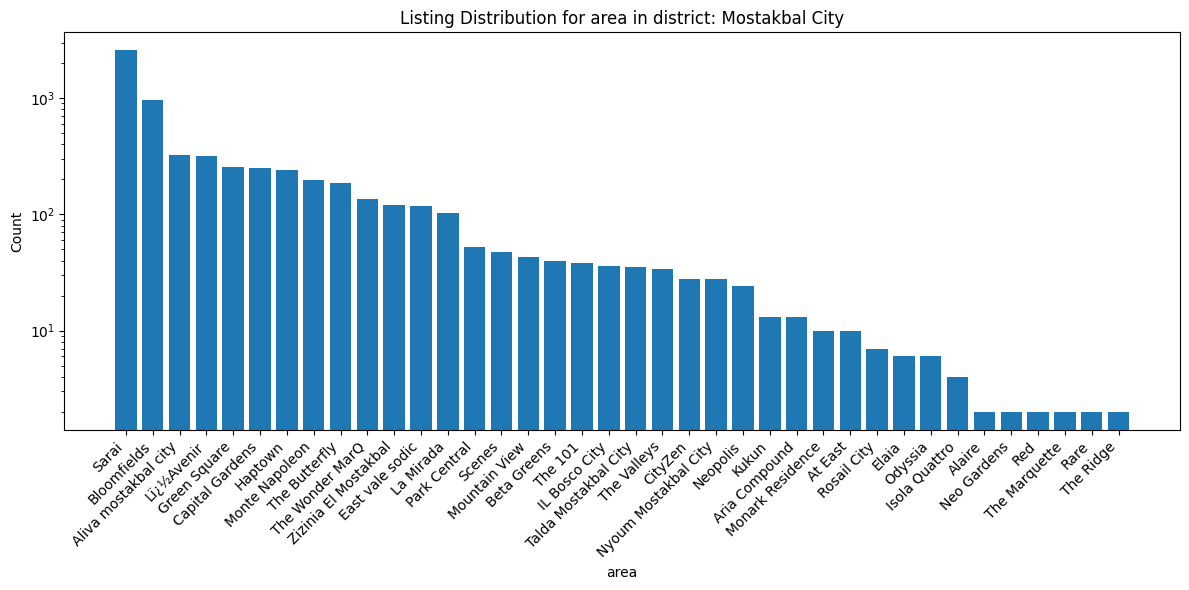

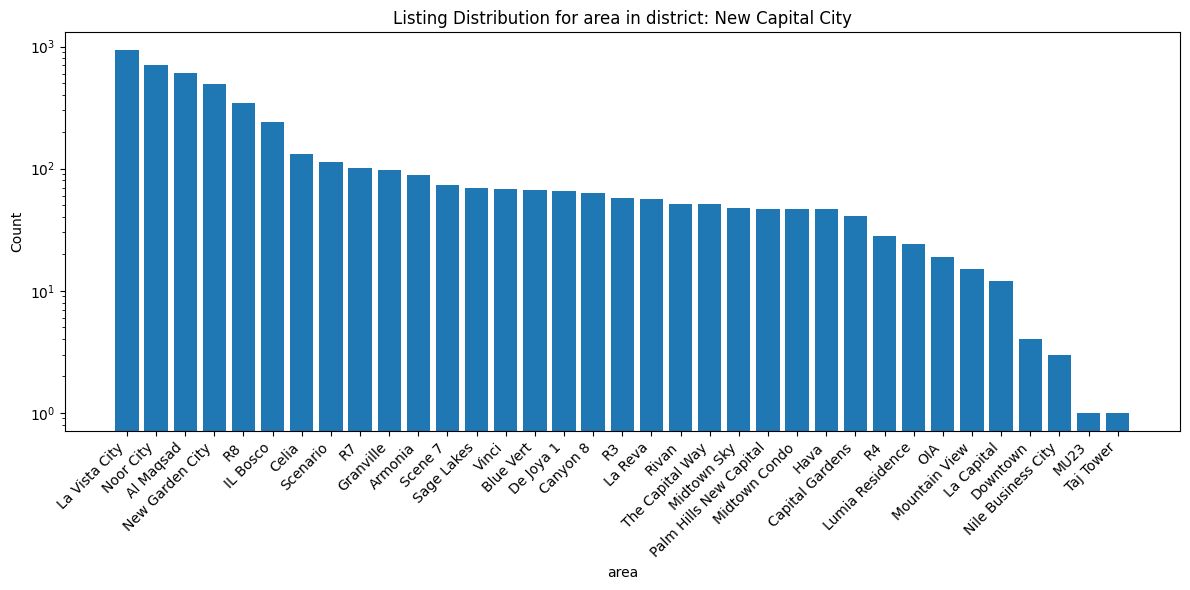

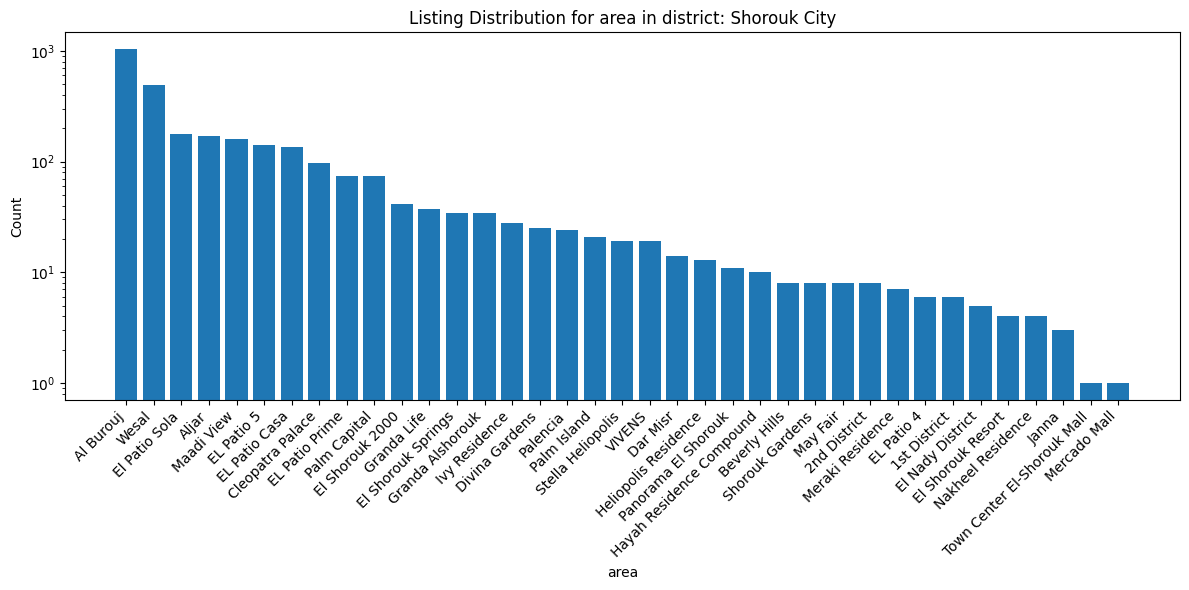

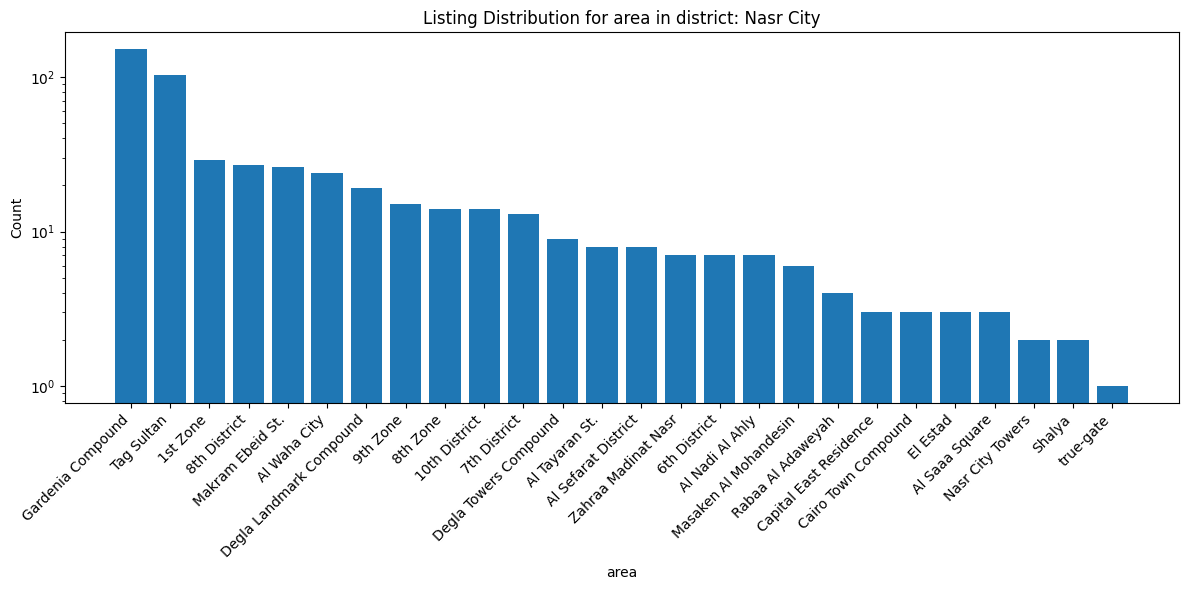

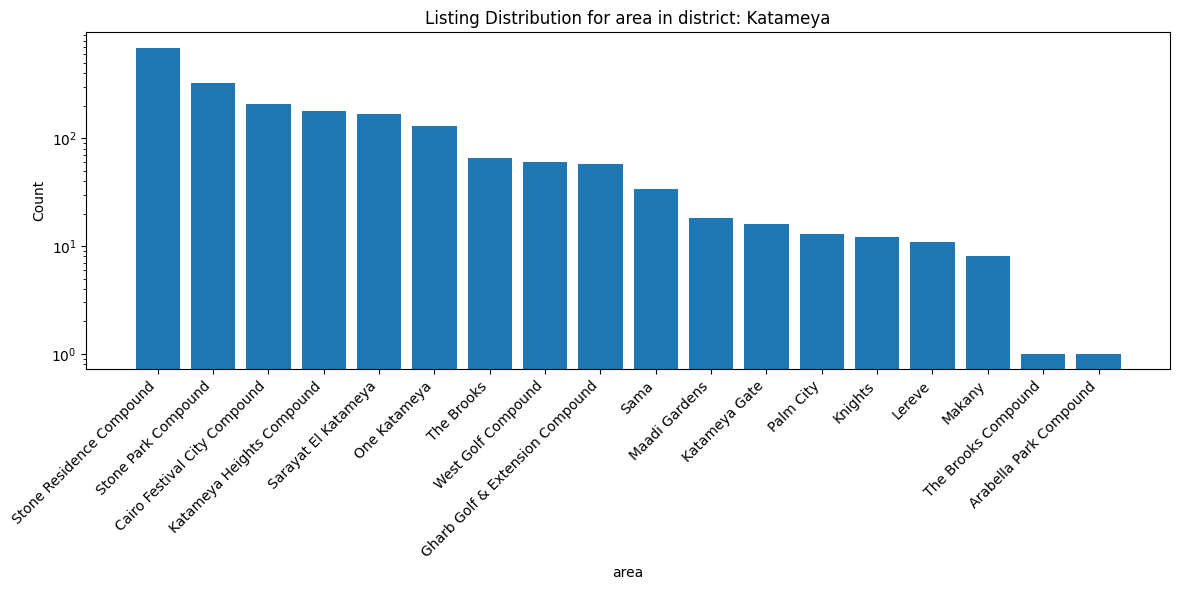

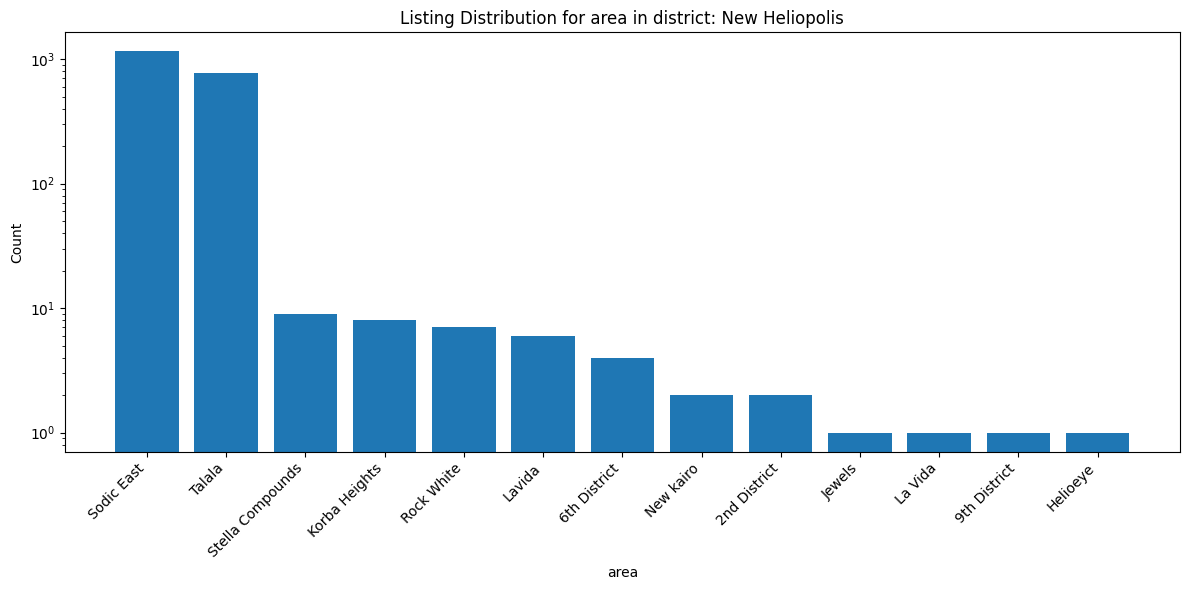

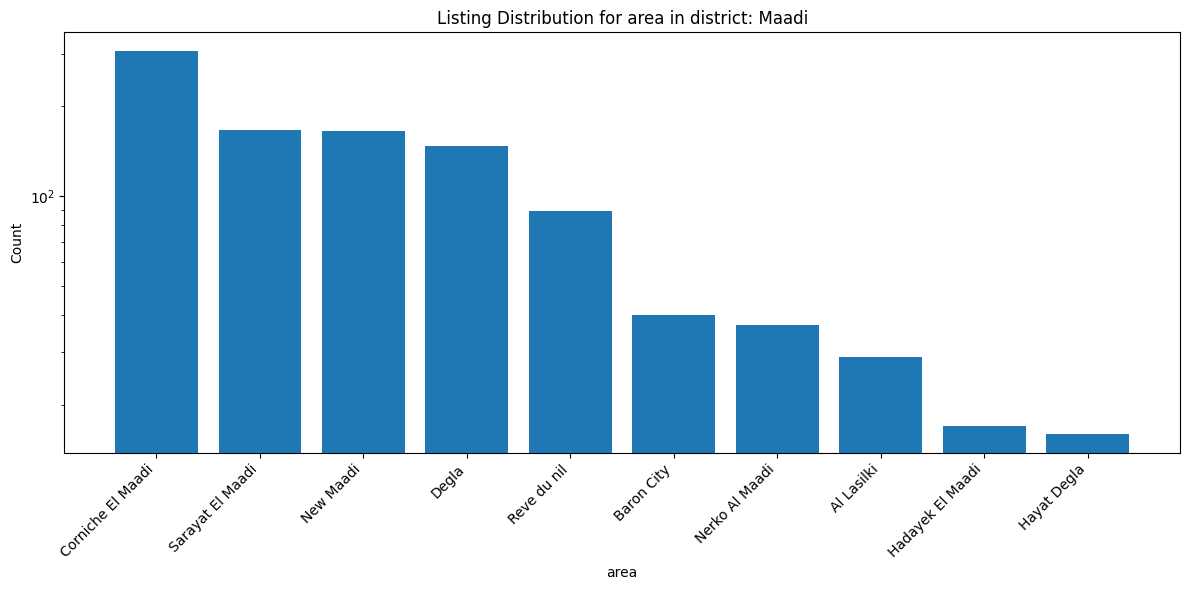

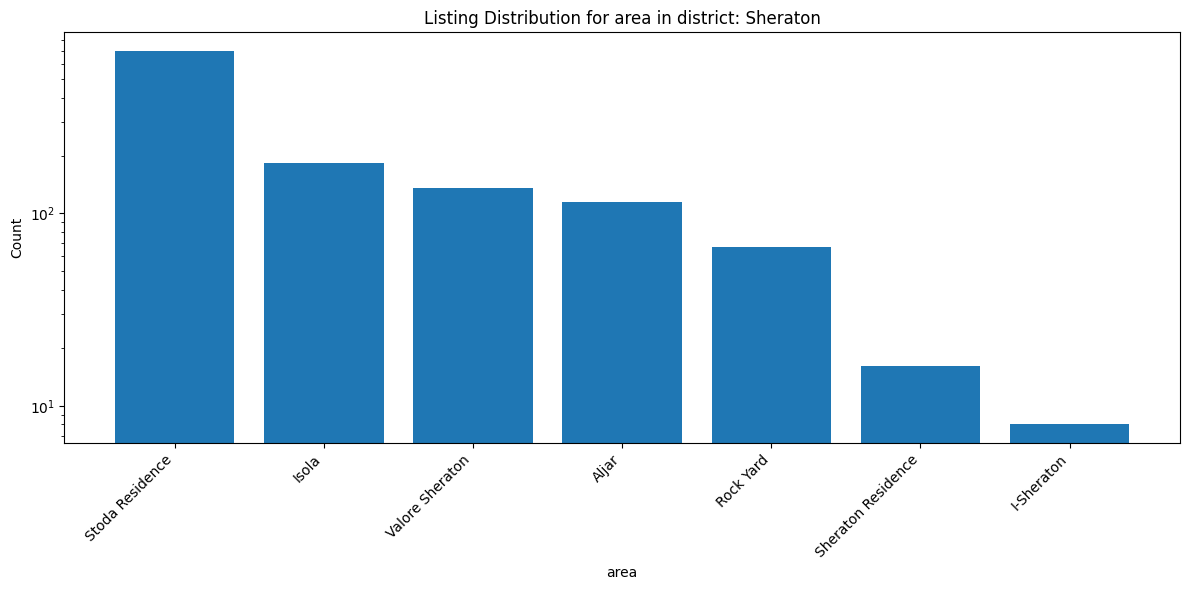

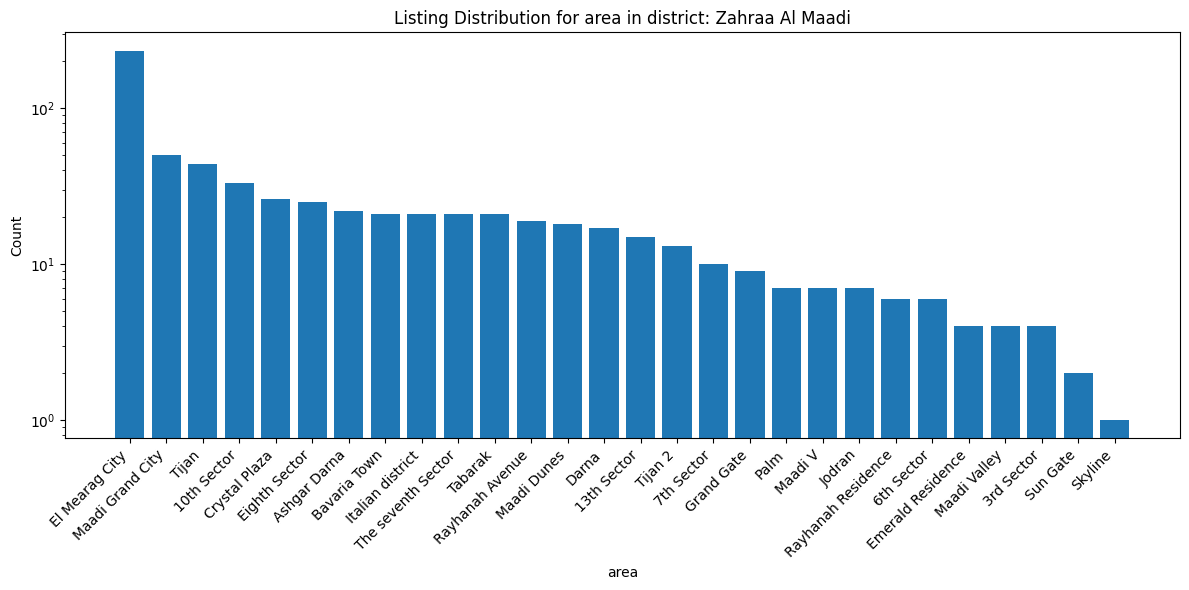

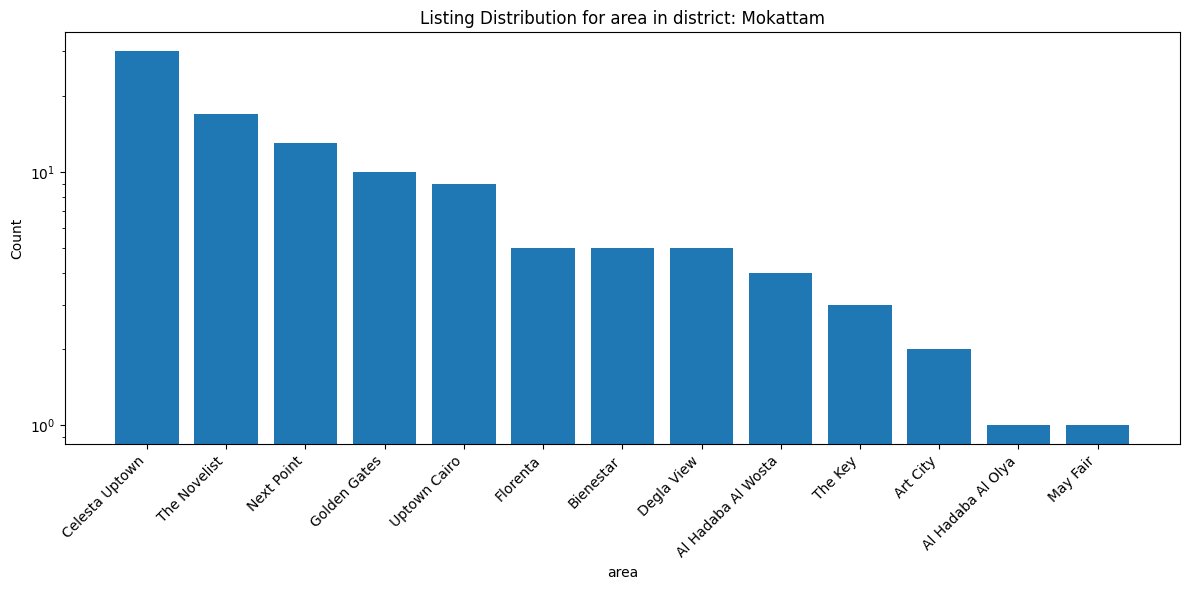

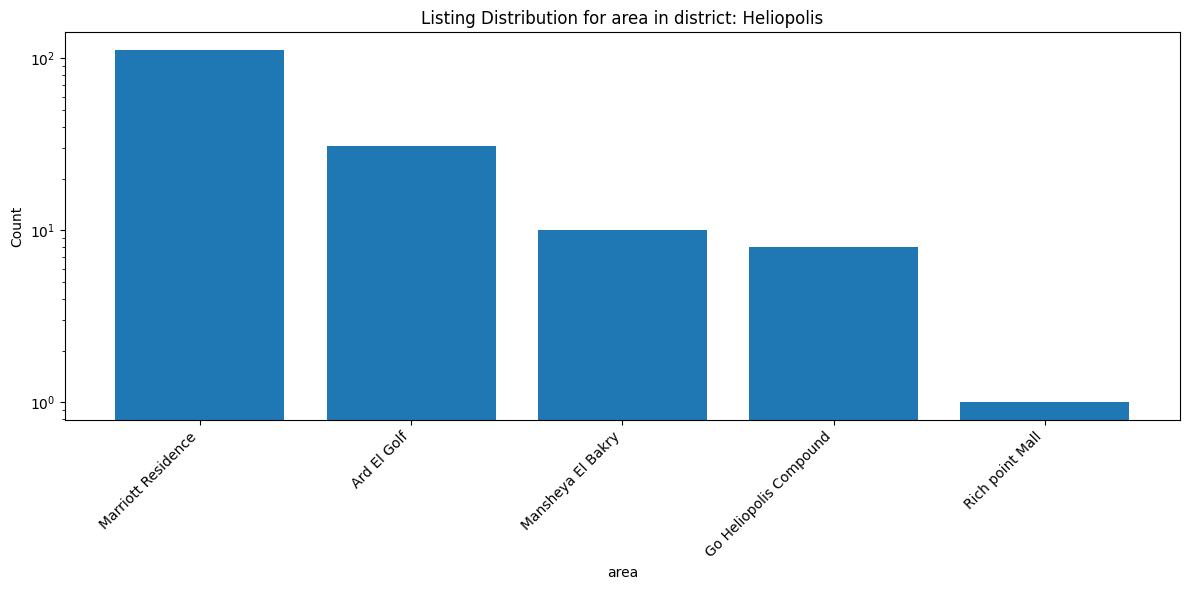

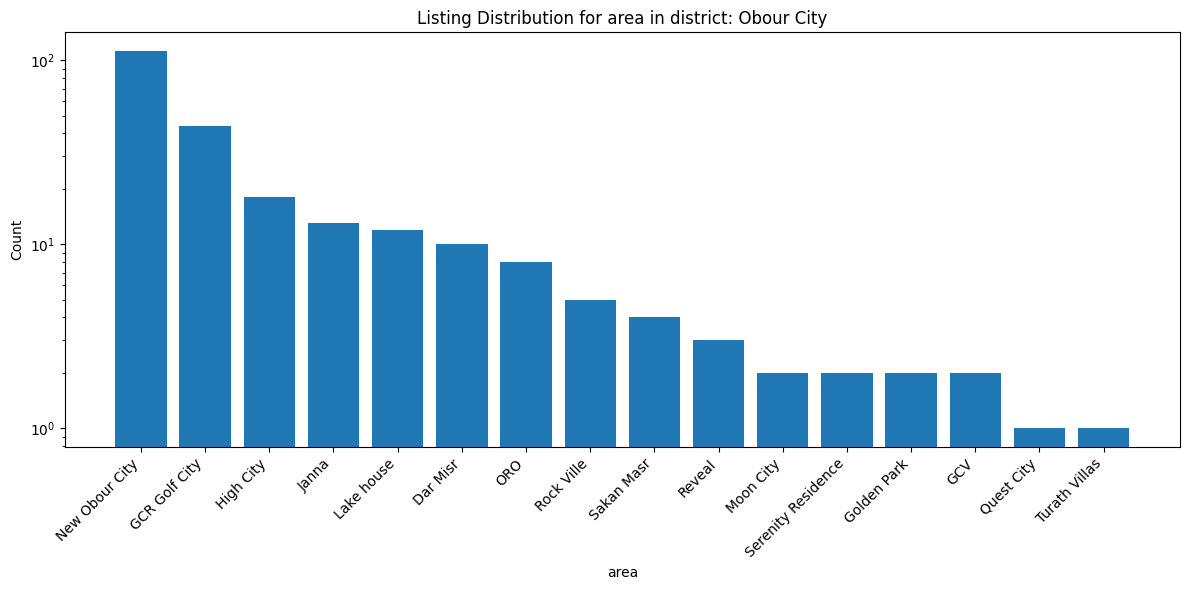

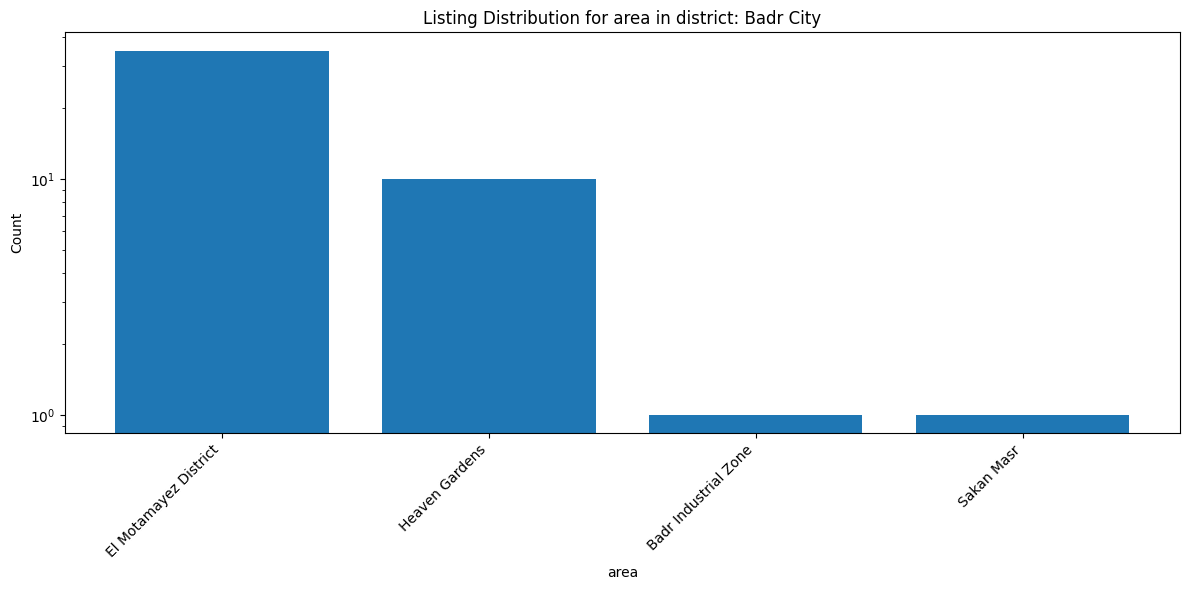

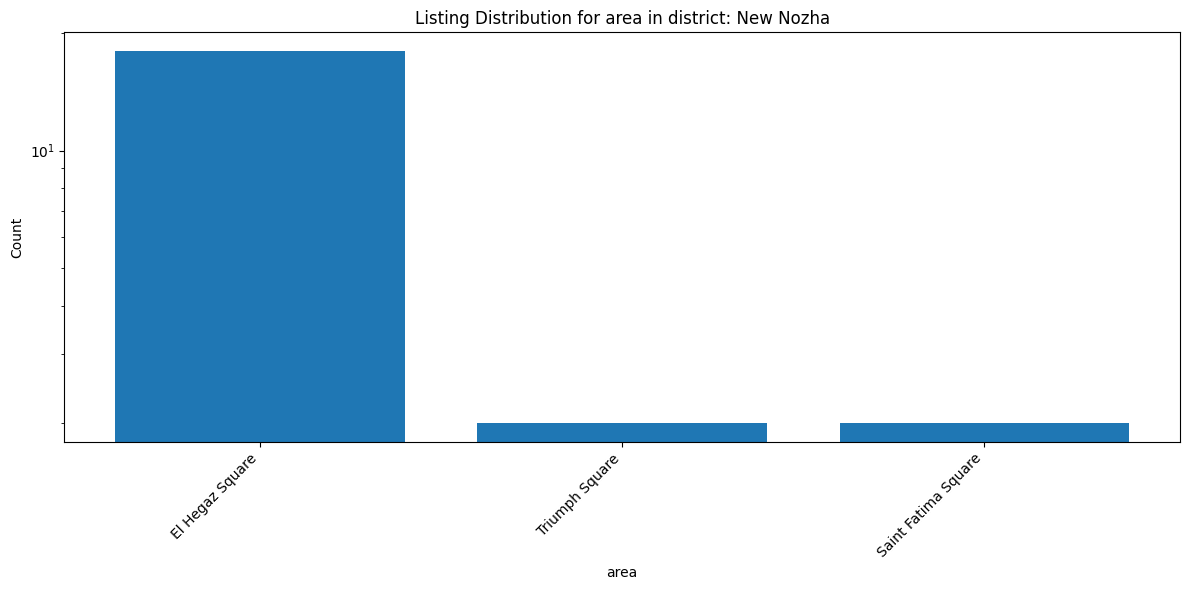

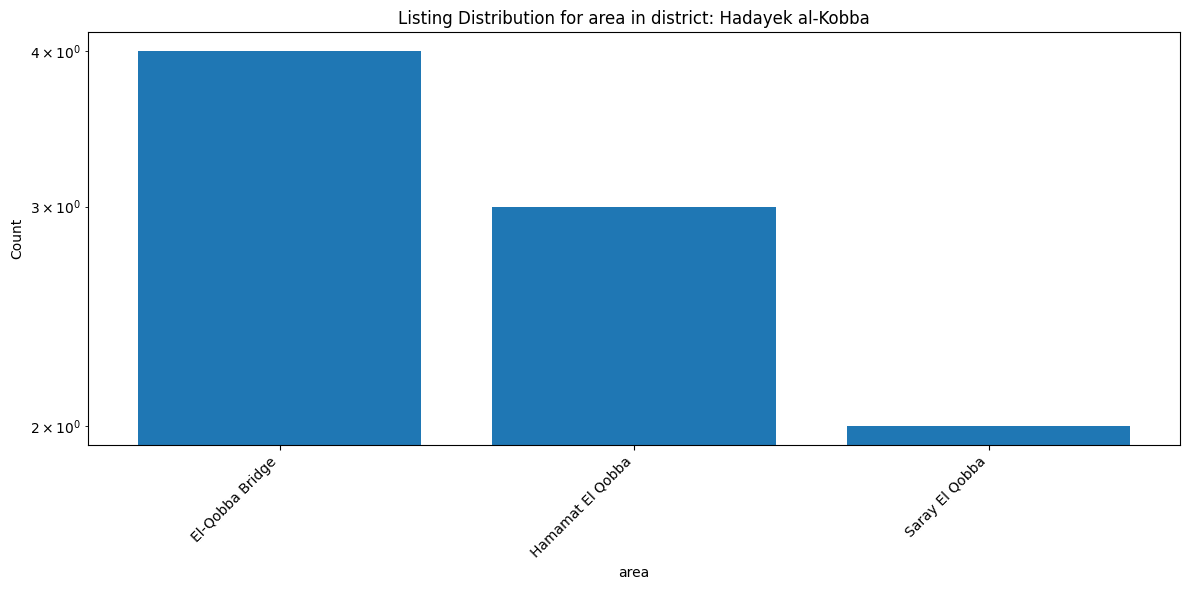

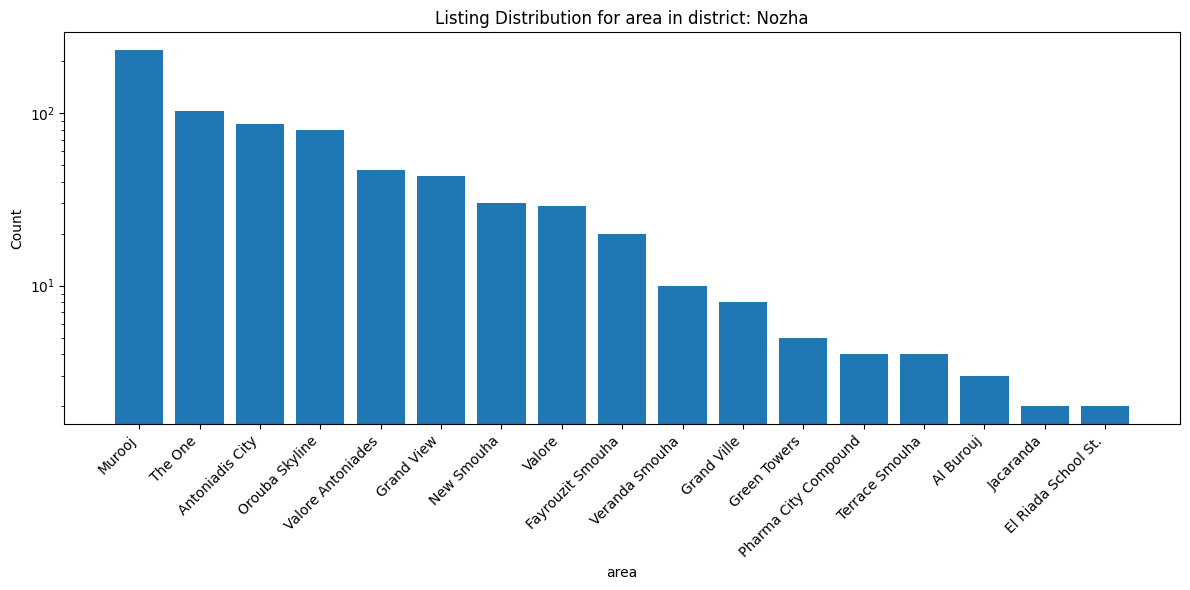

In [27]:
# First thing let's look at each variables individually understand them and build up from there 
# Let's start simply by district
districts = df['district'].unique()
for district in districts:
    data = df[df['district'] == district]
    if len(data['area'].unique()) > 2: 
        counts = data['area'].value_counts()

        plt.figure(figsize=(12, 6))
        plt.bar(counts.index, counts.values)
        plt.yscale('log')
        plt.xticks(rotation=45, ha='right')
        plt.xlabel('area')
        plt.ylabel('Count')
        plt.title(f'Listing Distribution for area in district: {district}')
        plt.tight_layout()
        plt.show()
    

In [ ]:
areas = df['area'].unique()
for area in areas:
    print(df[df['area'] == area]['neighborhood'].unique())

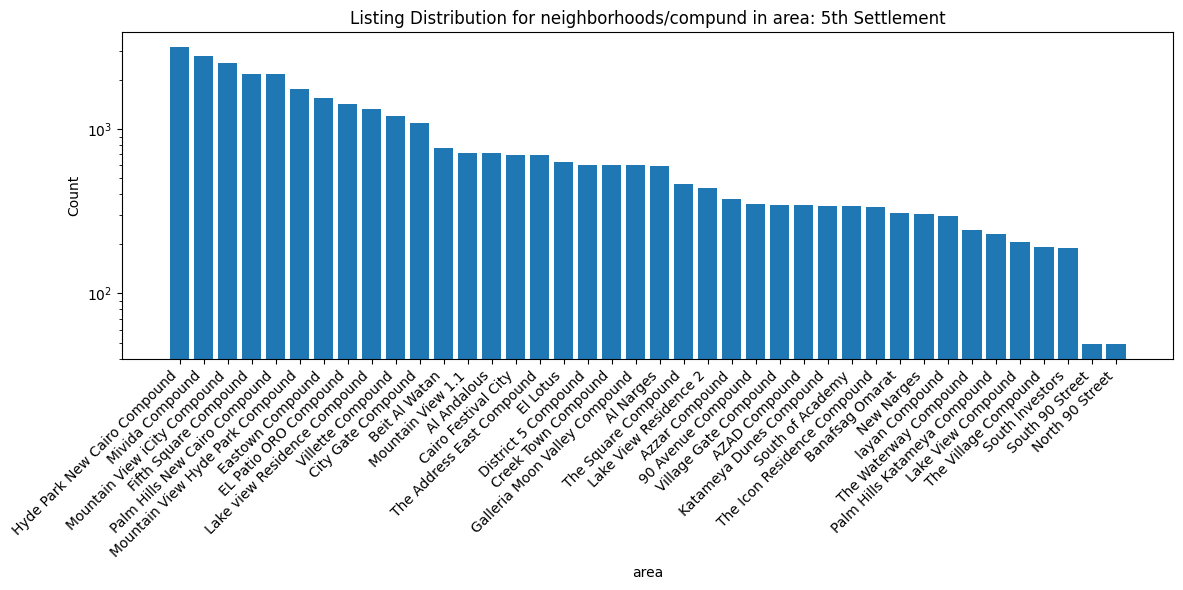

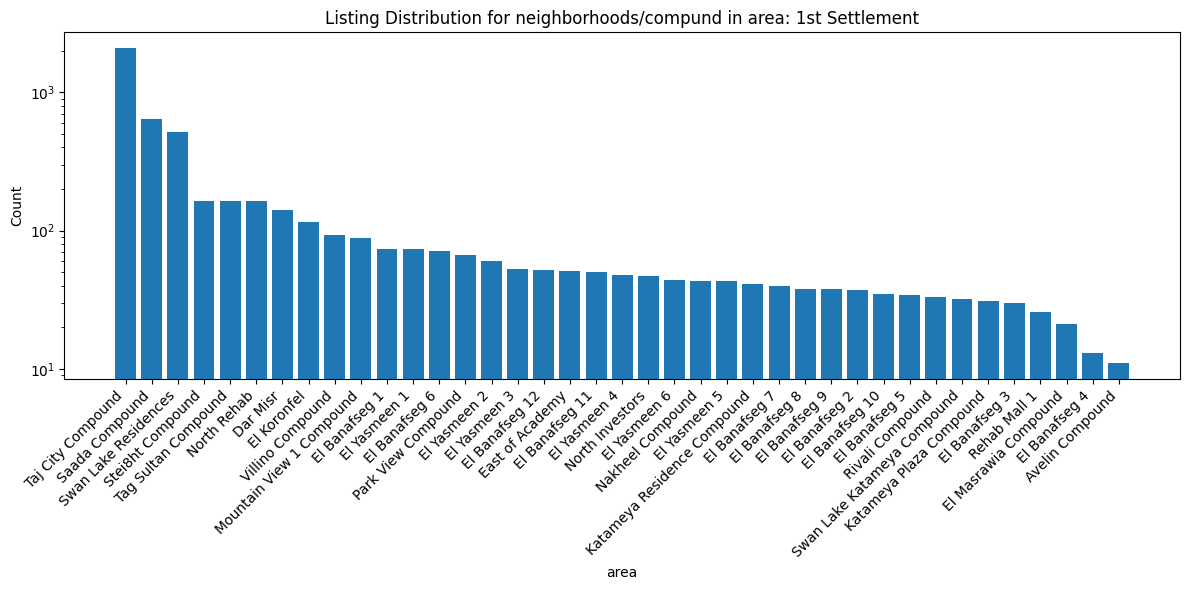

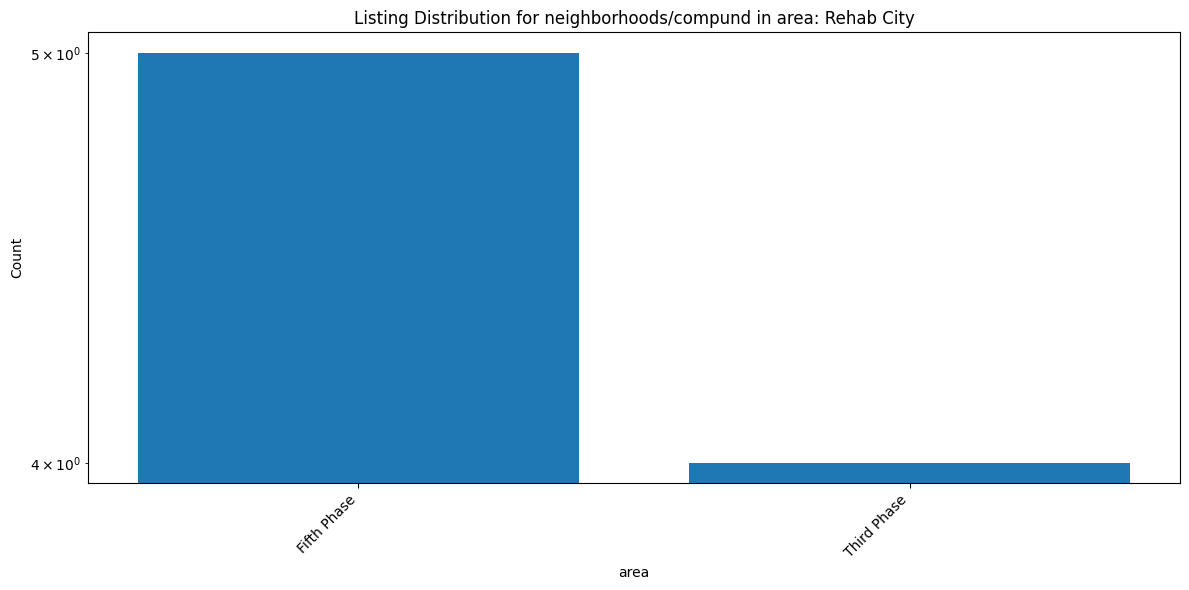

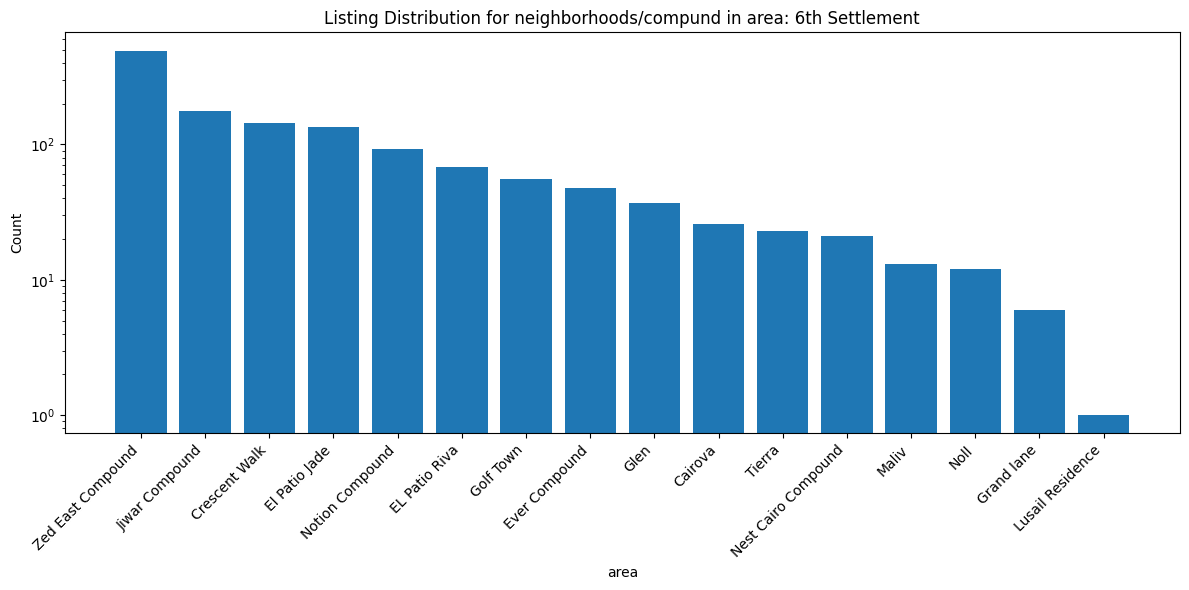

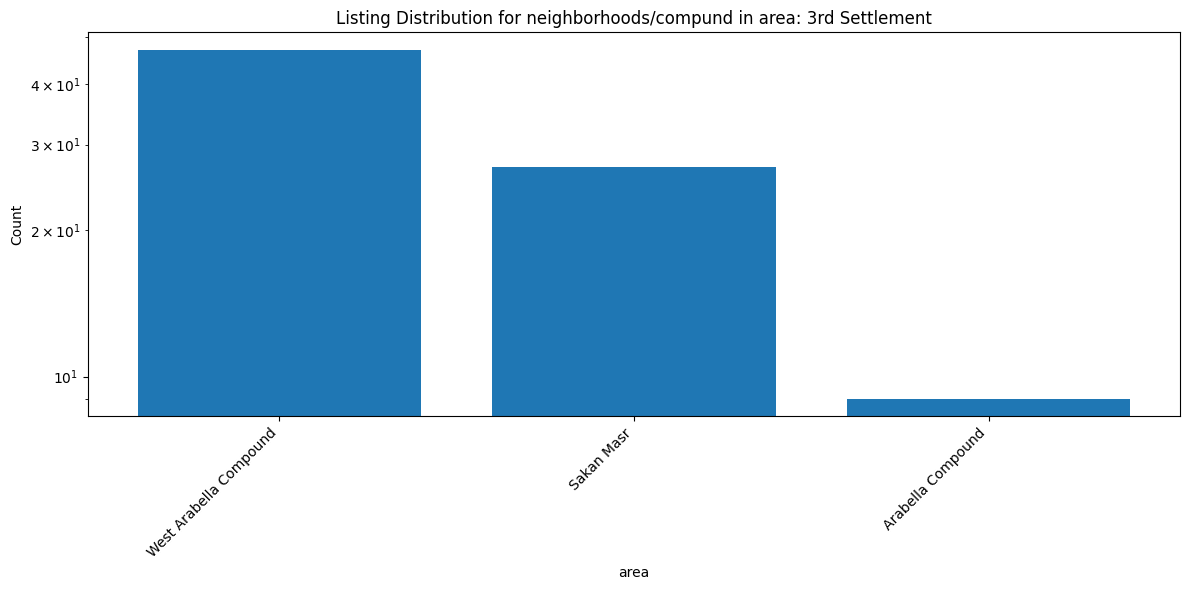

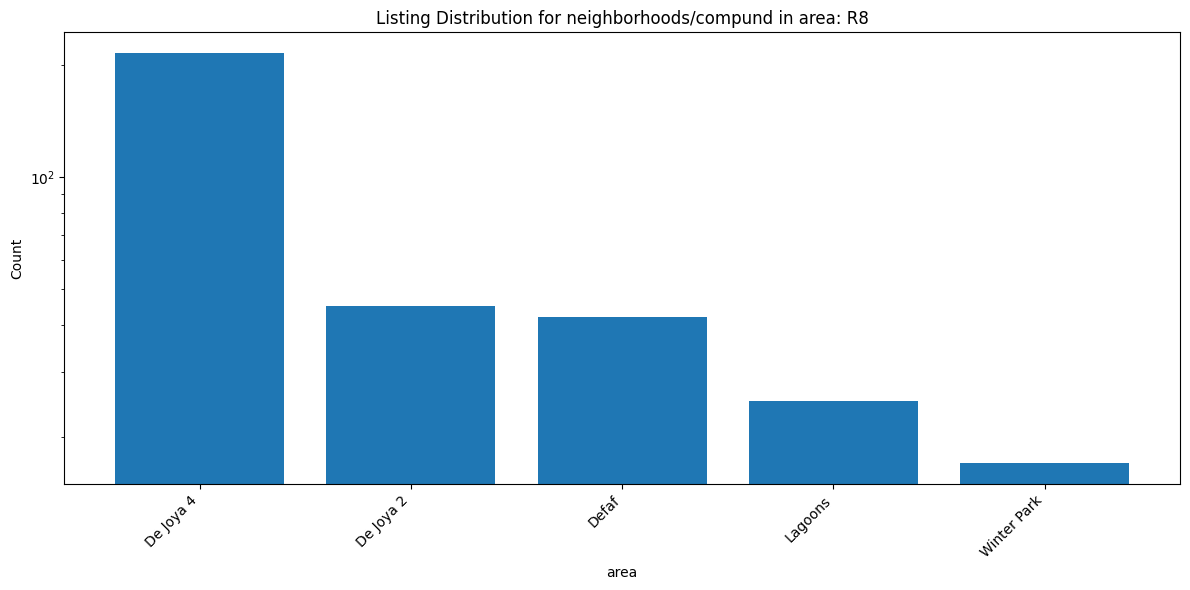

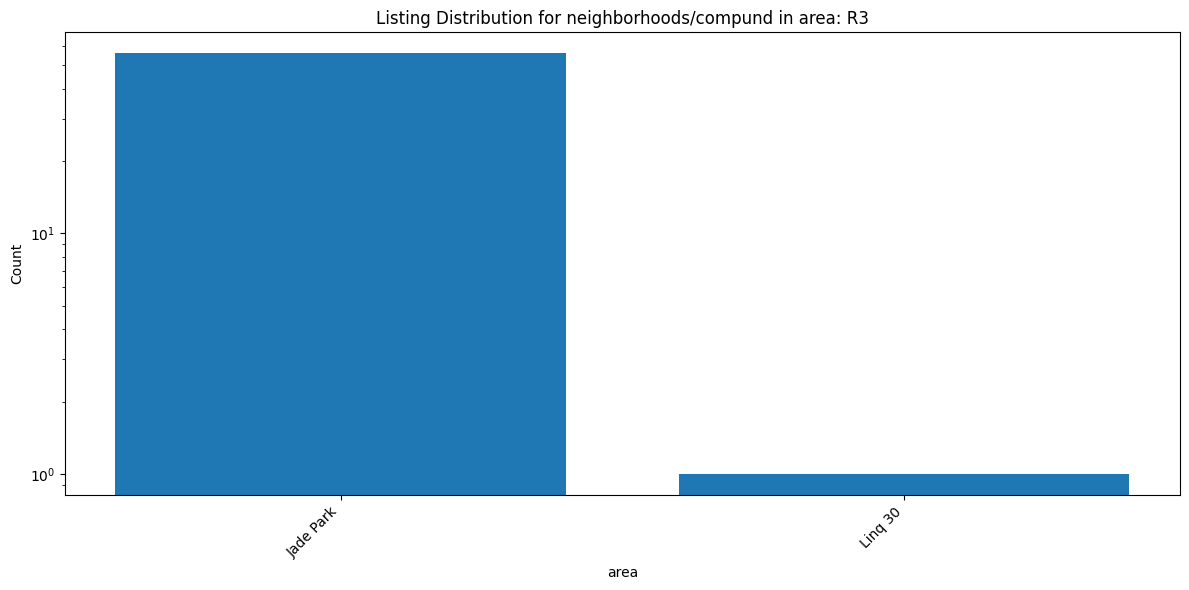

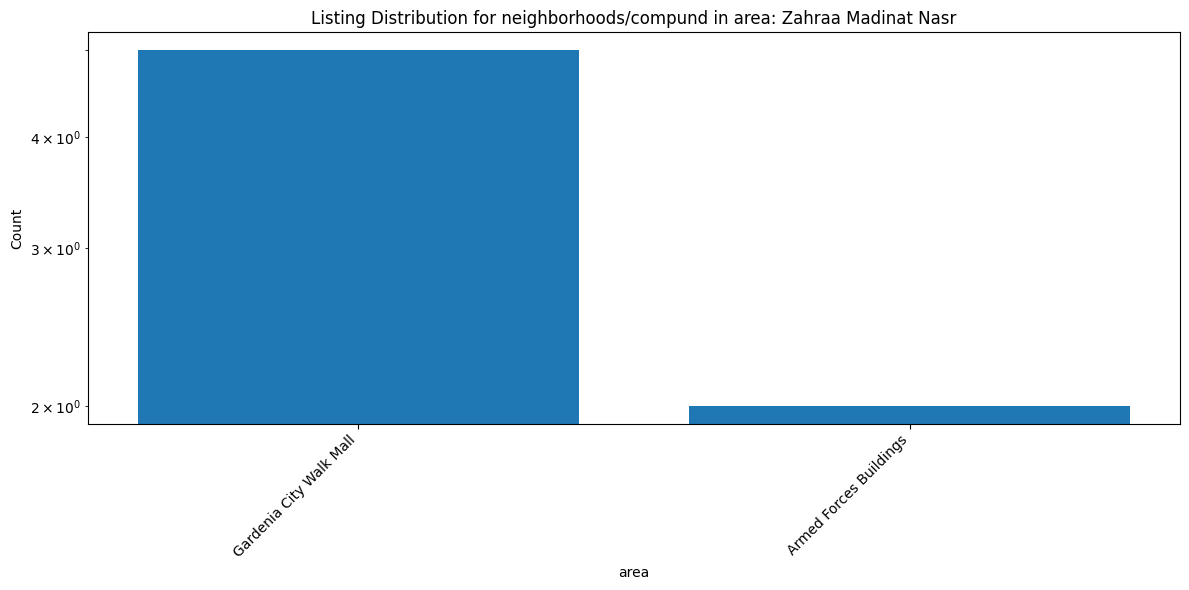

In [35]:
# First thing let's look at each variables individually understand them and build up from there 
# Let's start simply by district
districts = df['district'].unique()
for district in districts:
    data = df[df['district'] == district]
    if len(data['area'].unique()) > 2: 
        areas = data['area'].unique()
        for area in areas:
            niegbhorhoods = data[data['area'] == area]['neighborhood'].unique()
            if len(niegbhorhoods ) > 1:

                counts = data[data['area'] == area]['neighborhood'].value_counts()

                plt.figure(figsize=(12, 6))
                plt.bar(counts.index, counts.values)
                plt.yscale('log')
                plt.xticks(rotation=45, ha='right')
                plt.xlabel('area')
                plt.ylabel('Count')
                plt.title(f'Listing Distribution for neighborhoods/compund in area: {area}')
                plt.tight_layout()
                plt.show()
        

In [ ]:
## This made me realease that some areas doesn't need the neighborhood level as there are lists that are on the area level that are not tied to specific neighborhood 
## Like in rehab city it should contain more tha 1k properties it contains only 5. Unfortantely this could easily be handled I will just scrape the data and

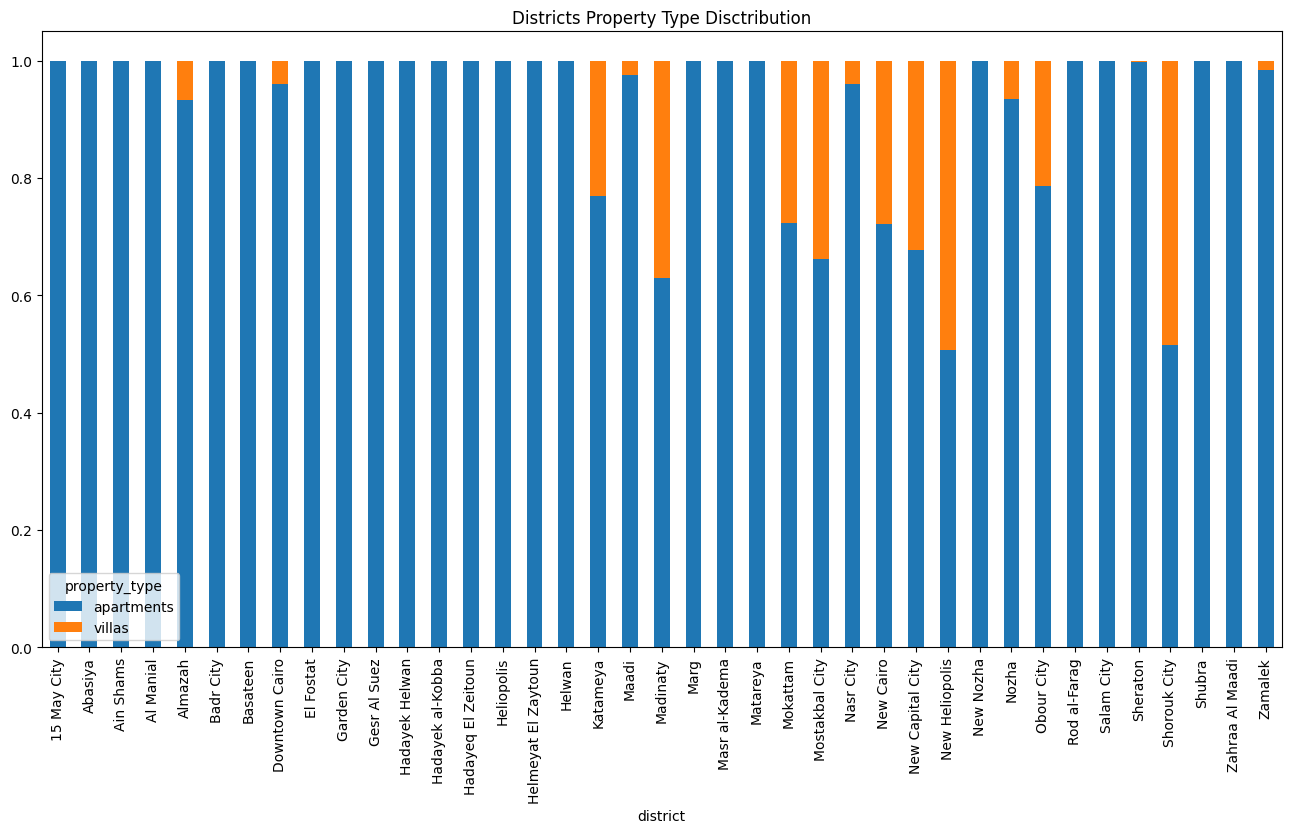

In [7]:
# First let's get an overview of what is the location distribution of our data district level 
# and in each district what are the domninat property type 
data = df.groupby('district')['property_type'].value_counts(normalize=True)
plot_df = data.unstack(level='property_type').fillna(0)
plot_df = plot_df.loc[(plot_df !=0).any(axis=1), (plot_df !=0).any(axis=0)]
plot_df.plot(kind='bar', stacked= True,figsize=(16,8))
plt.title('Districts Property Type Disctribution')
plt.show()

### From the above plot we can interpret the following:
1. The obvious the number of apartments is way more the number of villas 
2. New Heliopolis & Shrouk city contains the highest villas distribution compared to other district
3. Villas are only found in specific districts 

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70344 entries, 0 to 70343
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        70342 non-null  string        
 1   city                         70344 non-null  string        
 2   district                     70344 non-null  string        
 3   area                         63779 non-null  string        
 4   neighborhood                 40625 non-null  string        
 5   property_type                70344 non-null  string        
 6   sale_or_rent                 70344 non-null  string        
 7   price                        70344 non-null  Int64         
 8   seller_name                  70344 non-null  string        
 9   property_subtype             70344 non-null  string        
 10  bedrooms                     70344 non-null  string        
 11  bathrooms                    70344 non-nu

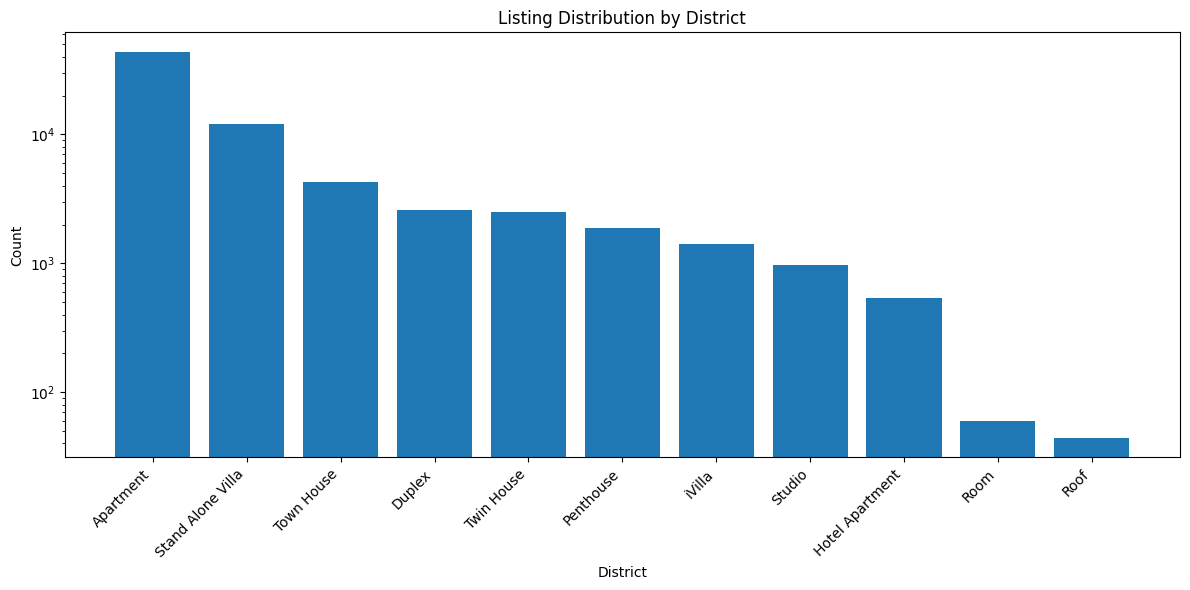

In [ ]:
# First thing let's look at each variables individually understand them and build up from there 
# Let's start simply by district
counts = df['property_subtype'].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(counts.index, counts.values)
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.xlabel('District')
plt.ylabel('Count')
plt.title('Listing Distribution for property subtype')
plt.tight_layout()
plt.show()

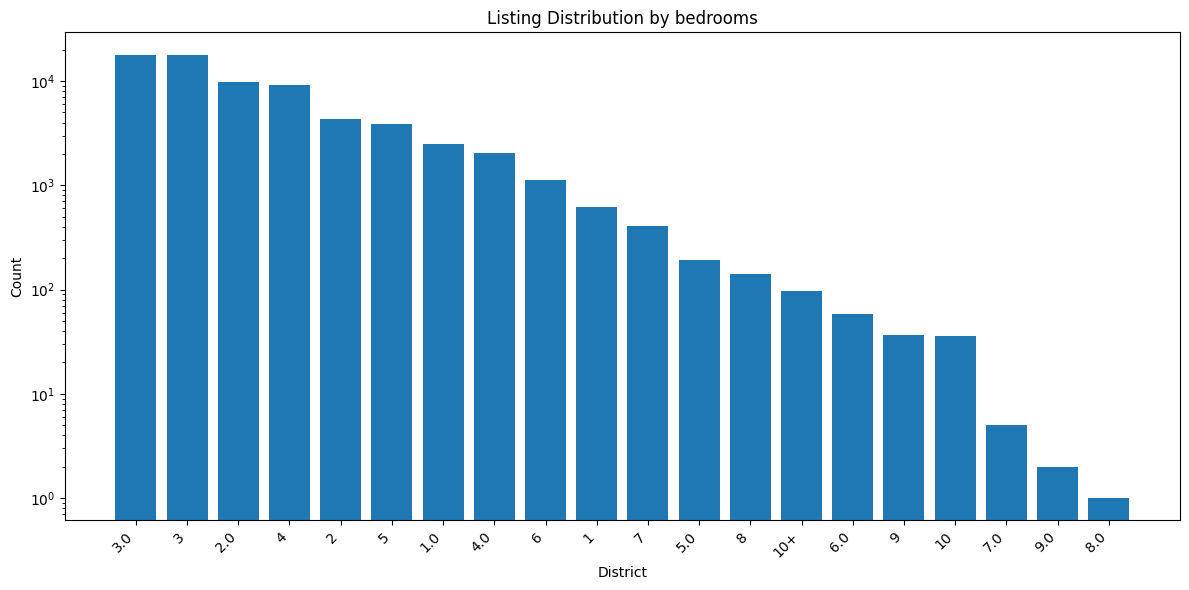

In [42]:
# First thing let's look at each variables individually understand them and build up from there 
# Let's start simply by district
counts = df['bedrooms'].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(counts.index, counts.values)
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.xlabel('District')
plt.ylabel('Count')
plt.title('Listing Distribution by bedrooms')
plt.tight_layout()
plt.show()


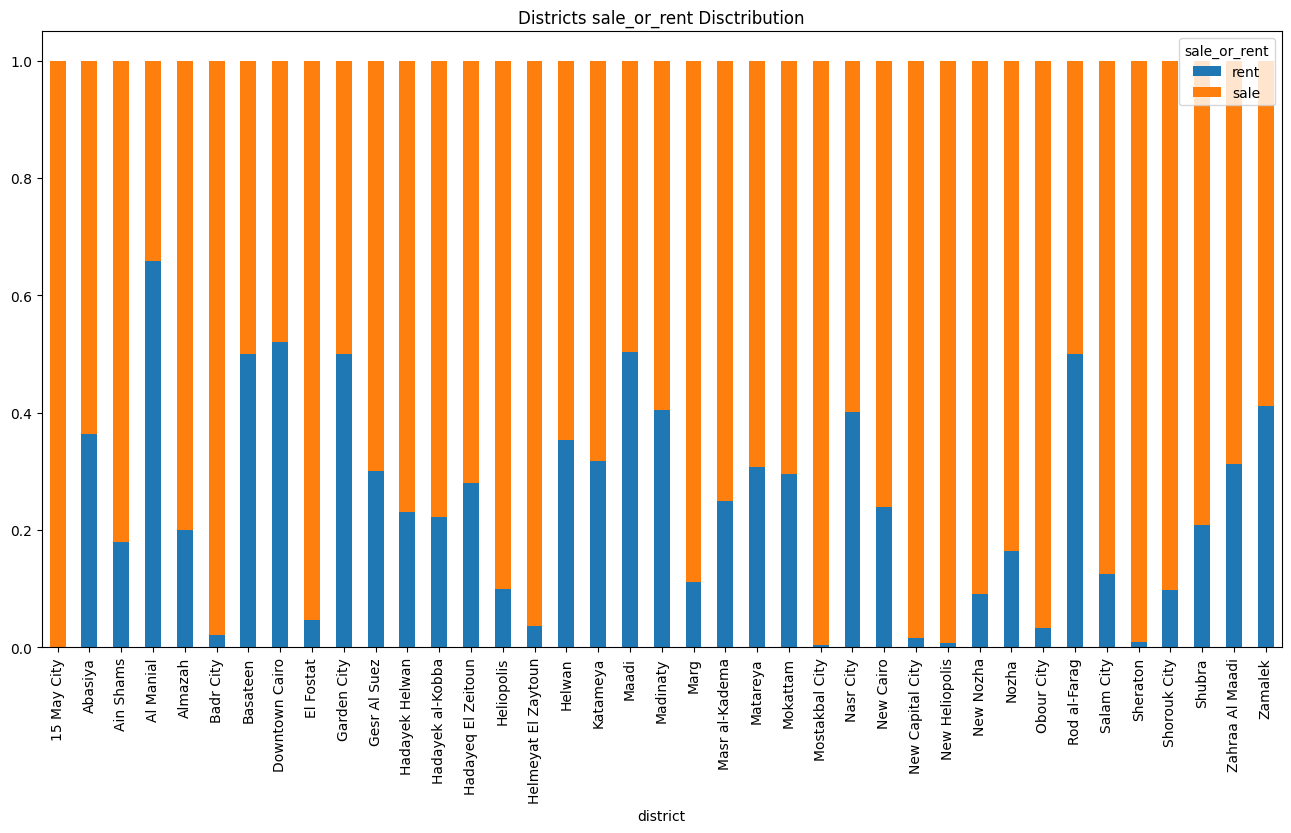

In [9]:
# First let's get an overview of what is the location distribution of our data district level 
# and in each district what are the domninat property type 
data = df.groupby('district')['sale_or_rent'].value_counts(normalize=True)
plot_df = data.unstack(level='sale_or_rent').fillna(0)
plot_df = plot_df.loc[(plot_df !=0).any(axis=1), (plot_df !=0).any(axis=0)]
plot_df.plot(kind='bar', stacked= True,figsize=(16,8))
plt.title('Districts sale_or_rent Disctribution')
plt.show()

In [10]:
# What interesting about the above graph that in District Like al manial it contains more rental properties than on sale properties